In [19]:
import numpy as np
import math
import random
import matplotlib.pyplot as plt

In [20]:
## Reading file into a numpy array
x1_train,x2_train,t_train = np.loadtxt("/content/dev.txt", delimiter=',', unpack=True)
x1_dev,x2_dev,t_dev = np.loadtxt("/content/dev.txt", delimiter=',', unpack=True)
print(len(x1_train))

1000


In [21]:
x_train = [x1_train,x2_train]
x_train = np.asarray(x_train)
x_train = x_train.T
x_train = np.reshape(x_train,(len(x_train),2,1))

x_dev = [x1_dev,x2_dev]
x_dev = np.asarray(x_dev)
x_dev = x_dev.T
x_dev = np.reshape(x_dev,(len(x_dev),2,1))

In [22]:
X_train = [x_train[:500,:,:],x_train[500:,:,:]]
X_train = np.asarray(X_train)

X_dev = [x_dev[:500,:,:],x_dev[500:,:,:]]
X_dev = np.asarray(X_dev)

In [23]:
# K-means algorithm
def K_means(X,Z,K,runs): 
  N = len(X) 
  d = len(X[0])
  r = np.zeros(N) 
  for run in range(runs):
    for n in range(N):
      dist = math.inf
      cluster = -1
      for k in range(K):
        if np.linalg.norm(X[n]-Z[k]) < dist:
          dist = np.linalg.norm(X[n]-Z[k])
          cluster = k
        elif np.linalg.norm(X[n]-Z[k]) == dist:
          if random.randint(0,1) == 1:
            cluster = k
      r[n] = cluster
    for k in range(K):
      sum = np.zeros((d,1))
      cnt = 0
      for n in range(N):
        if r[n]==k:
          sum += X[n]
          cnt += 1  
      if cnt!=0:  
        Z[k] = sum/cnt # ask TA
      else:
        Z[k] = np.array(d)
  return Z,r

# Computes the multivariate gaussian function's value at point "x"
def Multivariate_Gaussian(x,mu,sigma):
    n = len(mu)
    sigma_det = np.linalg.det(sigma)
    sigma_inv = np.linalg.inv(sigma)
    denom = np.sqrt(((2*np.pi)**n)*sigma_det)
    fac = ((x-mu).T)@(sigma_inv)@(x-mu)
    return np.exp(-fac/2)/denom

# No of data points belonging to the kth cluster
def Cnt(X,k,r):
  N = len(X) 
  cnt = 0
  for n in range(N):
    if r[n] == k:
      cnt += 1
  return cnt

# Computation of mixing coefficients of GMM
def Pi(k,N,gamma):
  sum = 0
  for n in range(N):
      sum += gamma[n,k]
  return sum/N

# Computation of means of the mixtures of GMM
def Mu(X,N,k,gamma):
  sum = np.zeros((len(X[0]),1))
  cnt = 0
  for n in range(N):
      sum += X[n]*gamma[n,k]
      cnt += gamma[n,k]
  return sum/cnt

# Covariance matrix estimation for kth cluster
def Sigma1(X,k,r,mu):
  N = len(X) 
  sum = np.zeros((len(X[0]),len(X[0])))
  cnt = 0
  for n in range(N):
    if r[n] == k:
      sum += (X[n]-mu)@((X[n]-mu).T)
      cnt += 1
  return sum/cnt

# Covariance matrix estimation for kth mixture of GMM
def Sigma2(X,k,mu,gamma):
  N = len(X)
  sum = np.zeros((len(X[0]),len(X[0])))
  cnt = 0 
  for n in range(N):
    sum += gamma[n,k]*((X[n]-mu)@((X[n]-mu).T))
    cnt += gamma[n,k]
  return sum/cnt

# Computation of responsibilities of GMM
def Gamma(x,k,K,pi,mu,sigma):
  sum = 0
  for i in range(K):
    sum += pi[i]*Multivariate_Gaussian(x,mu[i],sigma[i])
  return (pi[k]*Multivariate_Gaussian(x,mu[k],sigma[k]))/sum

# EMM algorithm (for GMMs)
def EM(X,Z,K,runs1,runs2):    
  N = len(X) 
  mu,r = K_means(X,Z,K,runs1)
  pi = np.zeros(K)
  sigma = np.zeros((K,len(X[0]),len(X[0])))
  gamma = np.zeros((N,K))
  for k in range(K):
    sigma[k] = Sigma1(X,k,r,mu[k])
    pi[k] = Cnt(X,k,r)/N
  for run in range(runs2):
    for n in range(N):
      for k in range(K):
        gamma[n,k] = Gamma(X[n],k,K,pi,mu,sigma)
    for k in range(K):
      pi[k] = Pi(k,N,gamma)
      mu[k] = Mu(X,N,k,gamma)
      sigma[k] = Sigma2(X,k,mu[k],gamma)
  return pi,mu,sigma

# Computes the gaussian mixture's value at point "x"
def Gaussian_mixture(x,pi,mu,sigma):
  sum = 0
  K = len(pi)
  for k in range(K):
    sum += pi[k]*Multivariate_Gaussian(x,mu[k],sigma[k])
  return sum

In [24]:
K1 = 2

Z1 = np.zeros((K1,2,1))
for k in range(K1):
  Z1[k,0,0] = random.uniform(-12,0)
  Z1[k,1,0] = random.uniform(-12,0)

runs11 = 10
runs12 = 19

pi1,mu1,sigma1 = EM(X_train[0],Z1,K1,runs11,runs12)

K2 = 2

Z2 = np.zeros((K2,2,1))
for k in range(K2):
  Z2[k,0,0] = random.uniform(-12,0)
  Z2[k,1,0] = random.uniform(-12,0)

runs21 = 10
runs22 = 19
pi2,mu2,sigma2 = EM(X_train[1],Z2,K2,runs21,runs22)

pi = [pi1,pi2]
mu = [mu1,mu2]
sigma = [sigma1,sigma2]

In [25]:
N = len(x_train)
C = 2
S = np.zeros((N,C))
  
for n in range(N):
  for c in range(C):
    S[n,c] = Gaussian_mixture(x_train[n],pi[c],mu[c],sigma[c])/2

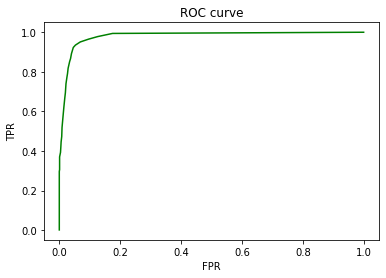

In [26]:
min = np.amin(S)
max = np.amax(S)

TPR11 = []
FPR11 = []

thresholds = np.linspace(min,max,100)

for threshold in thresholds:
  TP = FP = TN = FN = 0
  for i in range(N): 
    for j in range(C):
      if S[i,j] >= threshold:
        if t_train[i] == j+1:
          TP+=1
        else:
          FP+=1
      else:
        if t_train[i] == j+1:
          FN+=1 
        else:
          TN+=1
  TPR11.append(TP/(TP+FN))  # True positive rate
  FPR11.append(FP/(FP+TN))  # False positive rate

# plotting
plt.title("ROC curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.plot(FPR11, TPR11, color ="green")
plt.show()